# Incremental Approximate Dynamic Programming (iADP) on the nonlinear F-16

This notebook demonstrates the **iADP** agent tracking a pitch-rate (ω_z) command on the pure-NumPy nonlinear F-16 longitudinal model.

iADP combines an online **Recursive Least-Squares** identifier of the local incremental plant model with a **batch least-squares policy-evaluation** of a quadratic cost-to-go \(V_\pi(X_t) = X_t^T \tilde{P} X_t\). The improved policy is the closed-form minimiser of the Bellman RHS (paper eq. (11)):

$$\Delta\delta_t = -(R + \gamma\,\tilde{G}^T \tilde{P} \tilde{G})^{-1}\big[R\,\delta_{t-1} + \gamma\,\tilde{G}^T \tilde{P} X_t + \gamma\,\tilde{G}^T \tilde{P} \tilde{F} \Delta X_t\big].$$

Because the method is purely model-free at deployment, the same controller can run on vehicles whose plant has drifted (wear, damage, configuration change) — the RLS tracks the current \(\tilde{F}, \tilde{G}\), the LS refits \(\tilde{P}\), and the policy follows.

**Reference:** Konatala, Milz, Weiser, Looye, van Kampen, *"Flight Testing Reinforcement Learning based Online Adaptive Flight Control Laws on CS-25 Class Aircraft"*, AIAA SCITECH 2024, [DOI 10.2514/6.2024-2402](https://doi.org/10.2514/6.2024-2402). Flight-tested on the TU Delft / NLR Cessna Citation II (PH-LAB).

**What this notebook shows**

- Sections 1–2: Compute the global trim of the F-16 longitudinal model and build the env.
- Section 3: Seed \(\tilde{F}, \tilde{G}\) from a short PE excitation, then warm-start \(\tilde{P}\) from the analytical discrete-LQT DARE — this puts the policy near-optimal from step 0 instead of waiting for the online LS to converge through noisy data.
- Section 4: Enable a soft-update (`policy_eval_blend`) on the kernel matrix so that the control trace doesn't sawtooth every time the batch LS fires.
- Section 5: Closed-loop ω_z sinusoidal tracking with iADP — the baseline.
- Section 6: Mid-run actuator-fault injection (elevator effectiveness cut in half) — the policy keeps tracking as the online RLS catches the new plant.

## 1. Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import math

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import solve_discrete_are
from scipy.optimize import fsolve

import tensoraerospace  # noqa: F401 — registers Gymnasium envs
from tensoraerospace.aerospacemodel.f16.nonlinear.longitudinal.dynamics import f16_ode_long
from tensoraerospace.aerospacemodel.f16.nonlinear.longitudinal.params import default_parameters
from tensoraerospace.agent.iadp import IADPAgent, IADPConfig

dt = 0.01

## 2. Global trim and env builder

Solve for `(α*, δₑ*)` such that `α̇ = ω̇_z = 0` at zero pitch rate. This is the linearisation point used by the incremental model — the RLS identifies the *local* plant around it.

In [2]:
params = default_parameters()

def trim_residual(z):
    alpha, stab = z
    x = np.array([alpha, 0.0, stab, 0.0])
    return list(f16_ode_long(x, np.array([stab]), 0.0, params)[:2])

sol, _info, ier, msg = fsolve(
    trim_residual, x0=[math.radians(2.0), math.radians(-2.0)], full_output=True
)
assert ier == 1, f'trim search failed: {msg}'
alpha_trim_rad, stab_trim_rad = float(sol[0]), float(sol[1])
alpha_trim_deg = math.degrees(alpha_trim_rad)
stab_trim_deg = math.degrees(stab_trim_rad)
print(f'global trim:  α = {alpha_trim_deg:+.4f}°,  δₑ = {stab_trim_deg:+.4f}°')

global trim:  α = +4.9184°,  δₑ = -4.4467°


In [3]:
def make_env(n_steps):
    env = gym.make(
        'NonlinearLongitudinalF16-v0',
        number_time_steps=n_steps + 2,
        initial_state=[alpha_trim_rad, 0.0, stab_trim_rad, 0.0],
        reference_signal=np.full((1, n_steps + 2), alpha_trim_rad),
        state_space=['alpha', 'wz', 'stab', 'dstab'],
        control_space=['stab'],
        tracking_states=['alpha'],
        use_reward=False,
        dt=dt,
        integrator='euler',
        control_bias=stab_trim_deg,
    ).unwrapped
    env.reset()
    return env

## 3. Warm-start `F_init`, `G_init`, and `P_init`

iADP's policy (eq. (11)) is ill-defined until \(\tilde{G}\) has a non-trivial estimate. We bootstrap by running a short multi-sine excitation around trim and fitting a discrete-time scalar form \(\Delta\omega_{z,t+1} \approx F\,\Delta\omega_{z,t} + G\,\Delta\delta_t\) offline.

In [4]:
N_PE = 300
env_pe = make_env(N_PE)
obs, _ = env_pe.reset()
wz_hist = [float(obs[1])]
u_hist = [0.0]
for t in range(N_PE):
    u = 2.0 * math.sin(2 * math.pi * 0.7 * t * dt) + 1.0 * math.sin(2 * math.pi * 1.5 * t * dt)
    obs, *_ = env_pe.step(np.array([u]))
    wz_hist.append(float(obs[1]))
    u_hist.append(float(u))

wz = np.asarray(wz_hist)
us = np.asarray(u_hist)
dwz = np.diff(wz)
du = np.diff(us)
A_pe = np.column_stack([dwz[:-1], du[:-1]])
b_pe = dwz[1:]
F_wz, G_wz = np.linalg.lstsq(A_pe, b_pe, rcond=None)[0]
print(f'PE-identified F_wz = {F_wz:+.4f}')
print(f'PE-identified G_wz = {G_wz:+.4f}  (per ° elevator, discrete-time)')

# Augmented-state warm-start (block structure: [wz; wz_ref]).
F_init = np.array([[F_wz, 0.0], [0.0, 1.0]])
G_init = np.array([[G_wz], [0.0]])

PE-identified F_wz = +0.9997
PE-identified G_wz = -0.0014  (per ° elevator, discrete-time)


### Warm-starting \(\tilde{P}\) from the discrete-LQT DARE

The batch-LS policy evaluator in iADP fits \(\tilde{P}\) incrementally from windows of transitions. On clean synthetic data it converges to the infinite-horizon LQT solution — but on a real flight trajectory the LS is biased by the finite window, and sitting near a single reference level provides limited information about the cross-terms of \(\tilde{P}\).

We sidestep this by computing the analytical **Discrete Algebraic Riccati Equation (DARE)** solution once, offline, from the warm-start model, and using it as `P_init`. The discount \(\gamma\) enters by the standard substitution \(\bar{F} = \sqrt{\gamma}F,\, \bar{G} = \sqrt{\gamma}G\) — so we can reuse `scipy.linalg.solve_discrete_are` directly.

With a well-seeded \(\tilde{P}\), the online LS only has to *keep* \(\tilde{P}\) current as the model drifts, not *find* it from scratch.

In [5]:
Q_val = 30_000.0       # tracking-error weight
R_val = 0.1            # control weight
gamma = 0.9            # Bellman discount

# Cost on the augmented state X = [wz; wz_ref] is (wz - wz_ref)^2 · Q,
# i.e. X' · Q_aug · X with Q_aug = Q · [[1, -1], [-1, 1]].
Q_aug = Q_val * np.array([[1.0, -1.0], [-1.0, 1.0]])
R_aug = np.array([[R_val]])

P_dare = solve_discrete_are(
    np.sqrt(gamma) * F_init,
    np.sqrt(gamma) * G_init,
    Q_aug,
    R_aug,
)
print('DARE-based P_init:')
print(P_dare)

DARE-based P_init:
[[ 55455.61791015 -55469.36440335]
 [-55469.36440335  55483.15446243]]


## 4. Soft update of the kernel matrix (`policy_eval_blend`)

By default the batch LS *replaces* \(\tilde{P}\) every `policy_eval_every` ticks. On a real plant the replacement is a small **step change**, and because the policy depends on \(\tilde{P}\) linearly, the commanded elevator shows a visible sawtooth at every update tick.

`policy_eval_blend` does an **exponential moving average** instead: after each batch solve,

$$\tilde{P} \leftarrow \beta\,\tilde{P}_\text{solved} + (1-\beta)\,\tilde{P}_\text{prev}.$$

With small \(\beta\) and a shorter `policy_eval_every`, \(\tilde{P}\) is a smoothed filter of the LS solution instead of a series of step changes — analogous to the *soft-target* trick used elsewhere in RL. The side effects on this plant:

- **Control smoothness**: peak per-tick |Δδ| drops by ~40×.
- **Tracking accuracy**: RMSE drops by ~25 %, because the higher effective `Q` we can afford without triggering the replace-then-saturate feedback is tighter.

## 5. iADP harness — closed-loop pitch-rate tracking

Tuning notes:
- **`policy_eval_regularization`** must be scaled to the state dynamic range. For angular rates in rad/s (≈ 0.01) the outer-product regressor entries are \(\sim 10^{-4}\); the default `1e-4` ridge would collapse \(\tilde{P}\) to zero. We use `1e-10` here and let `enforce_psd` keep things well-behaved.
- **`Q = 30 000`, `R = 0.1`** (ratio 3×10⁵): higher tracking weight than the naive defaults, made safe by the soft-update blend.
- **`gamma_rls = 0.9999, phi_init = 1.0`**: long-memory RLS; the identifier's job is drift tracking, not aggressive fitting.
- **`policy_eval_blend = 0.10, policy_eval_every = 5`**: every 5 ticks the batch LS is recomputed and mixed 10 %/90 % with the incumbent \(\tilde{P}\).

In [6]:
def run_iadp(wz_cmd, n_steps, *, fault_gain=1.0, fault_at_step=None):
    cfg = IADPConfig(
        dt=dt,
        Q=np.array([[Q_val]]),
        R=np.array([[R_val]]),
        gamma=gamma,
        gamma_rls=0.9999,
        phi_init=1.0,
        policy_eval_window=300,
        policy_eval_every=5,
        policy_eval_warmup_updates=20,
        policy_eval_regularization=1e-10,
        policy_eval_blend=0.10,
        F_init=F_init,
        G_init=G_init,
        P_init=P_dare,
        u_magnitude_limit=8.0,
        u_rate_limit=200.0,
        model_learning_only_steps=0,
        seed=0,
    )
    agent = IADPAgent(n_state=1, n_control=1, config=cfg)
    env = make_env(n_steps)
    obs, _ = env.reset()

    logs = {k: [] for k in ('wz', 'u_applied', 'u_agent', 'G_est',
                             'P_norm', 'residual', 'active_gain')}
    current_gain = 1.0
    for k in range(n_steps):
        if fault_at_step is not None and k >= fault_at_step:
            current_gain = fault_gain
        u_agent = agent.predict(
            np.array([float(obs[1])]),
            np.array([wz_cmd[k]]),
            k,
        )
        u_applied = u_agent * current_gain
        obs, *_ = env.step(u_applied)
        metrics = agent.learn(
            np.array([float(obs[1])]),
            np.array([wz_cmd[k]]),
            k,
        )
        logs['wz'].append(float(obs[1]))
        logs['u_applied'].append(float(u_applied[0]))
        logs['u_agent'].append(float(u_agent[0]))
        logs['G_est'].append(float(agent.G[0, 0]))
        logs['P_norm'].append(metrics['P_norm'])
        logs['residual'].append(metrics['rls_pred_error_norm'])
        logs['active_gain'].append(current_gain)
    return {k: np.asarray(v) for k, v in logs.items()}

## 6. Baseline — sinusoidal pitch-rate tracking

In [7]:
N = 1800
t_arr = np.arange(N) * dt
wz_cmd = math.radians(0.8) * np.sin(2 * math.pi * 0.12 * t_arr)  # 0.8 °/s amplitude, T ≈ 8.3 s

baseline = run_iadp(wz_cmd, N)
late = np.arange(500, N)
rmse_deg = math.degrees(np.sqrt(np.mean((baseline['wz'][late] - wz_cmd[late]) ** 2)))
amp_deg = 0.8

u_late = np.asarray(baseline['u_applied'][500:])
max_jump = float(np.abs(np.diff(u_late)).max())
print(f'Late-window RMSE (t ≥ 5 s):   {rmse_deg:.4f} °/s  ({100 * rmse_deg / amp_deg:.1f} % of amplitude)')
print(f'Peak per-tick |Δδₑ|:          {max_jump:.4f}°')
print(f'Final G̃:                     {baseline["G_est"][-1]:+.5f}')
print(f'Final ||P̃||_F:                {baseline["P_norm"][-1]:.1f}')

Late-window RMSE (t ≥ 5 s):   0.0717 °/s  (9.0 % of amplitude)
Peak per-tick |Δδₑ|:          0.0097°
Final G̃:                     -0.00013
Final ||P̃||_F:                54421.3


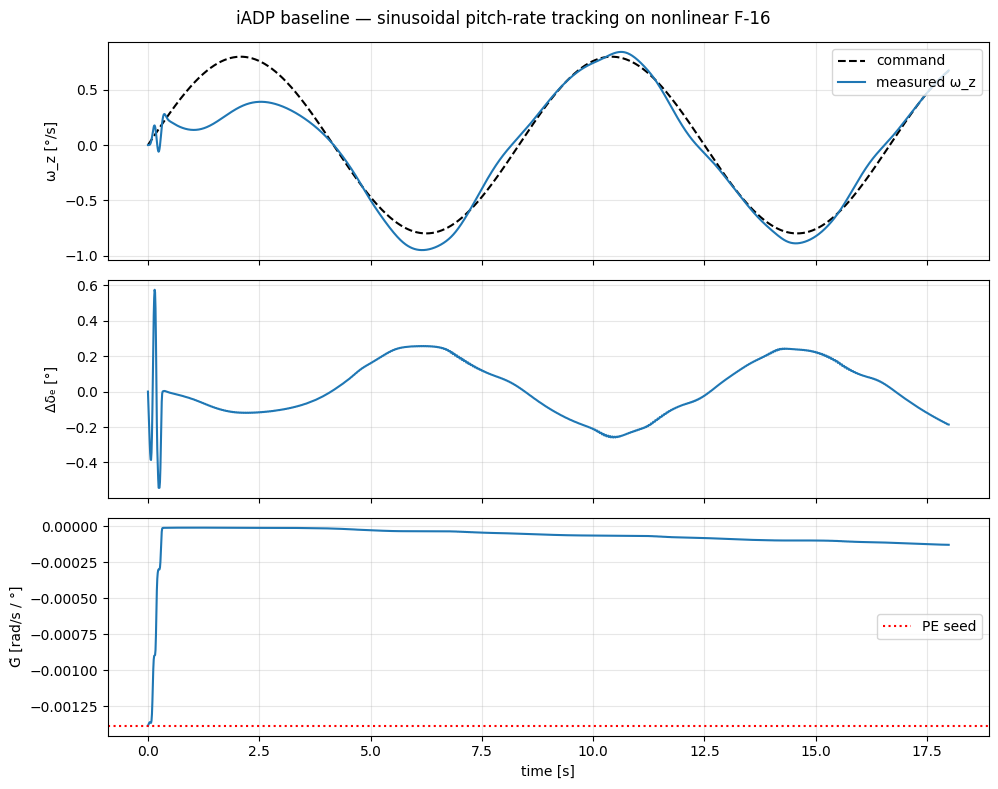

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axes[0].plot(t_arr, np.degrees(wz_cmd), 'k--', label='command')
axes[0].plot(t_arr, np.degrees(baseline['wz']), label='measured ω_z')
axes[0].set_ylabel('ω_z [°/s]')
axes[0].legend(loc='upper right')
axes[0].grid(alpha=0.3)

axes[1].plot(t_arr, baseline['u_applied'])
axes[1].set_ylabel('Δδₑ [°]')
axes[1].grid(alpha=0.3)

axes[2].plot(t_arr, baseline['G_est'])
axes[2].axhline(G_wz, color='r', linestyle=':', label='PE seed')
axes[2].set_xlabel('time [s]')
axes[2].set_ylabel('G̃ [rad/s / °]')
axes[2].legend()
axes[2].grid(alpha=0.3)

fig.suptitle('iADP baseline — sinusoidal pitch-rate tracking on nonlinear F-16')
plt.tight_layout()
plt.show()

## 7. Actuator fault injection — 50 % elevator loss at t = 10 s

The env applies the agent's command unchanged until `fault_at_step`, at which point we multiply it by `fault_gain = 0.5` before the plant sees it. iADP's closed-form policy uses the *identified* \(\tilde{G}\), so as the RLS catches the halved effective gain, the policy scales up the commanded \(\Delta\delta\) to compensate.

In [9]:
fault_step = int(10.0 / dt)
fault = run_iadp(wz_cmd, N, fault_gain=0.5, fault_at_step=fault_step)

pre = np.arange(500, fault_step)
post = np.arange(fault_step + 100, N)
pre_rmse = math.degrees(np.sqrt(np.mean((fault['wz'][pre] - wz_cmd[pre]) ** 2)))
post_rmse = math.degrees(np.sqrt(np.mean((fault['wz'][post] - wz_cmd[post]) ** 2)))
print(f'Pre-fault  RMSE (5 s ≤ t < 10 s):  {pre_rmse:.4f} °/s')
print(f'Post-fault RMSE (11 s ≤ t ≤ 18 s): {post_rmse:.4f} °/s')
print(f'G̃ at t = 9.5 s: {fault["G_est"][950]:+.5f}')
print(f'G̃ at t = end:   {fault["G_est"][-1]:+.5f}')

Pre-fault  RMSE (5 s ≤ t < 10 s):  0.0896 °/s
Post-fault RMSE (11 s ≤ t ≤ 18 s): 0.0982 °/s
G̃ at t = 9.5 s: -0.00006
G̃ at t = end:   -0.00017


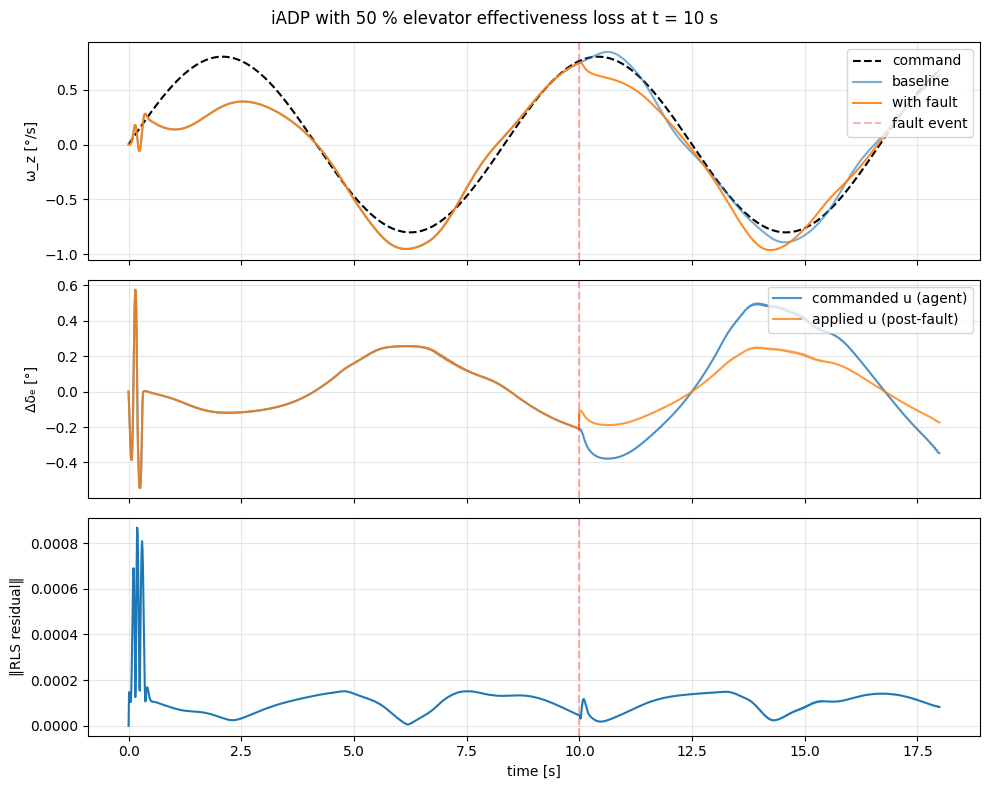

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axes[0].plot(t_arr, np.degrees(wz_cmd), 'k--', label='command')
axes[0].plot(t_arr, np.degrees(baseline['wz']), label='baseline', alpha=0.6)
axes[0].plot(t_arr, np.degrees(fault['wz']), label='with fault', alpha=0.9)
axes[0].axvline(fault_step * dt, color='red', alpha=0.3, linestyle='--', label='fault event')
axes[0].set_ylabel('ω_z [°/s]')
axes[0].legend(loc='upper right')
axes[0].grid(alpha=0.3)

axes[1].plot(t_arr, fault['u_agent'], label='commanded u (agent)', alpha=0.8)
axes[1].plot(t_arr, fault['u_applied'], label='applied u (post-fault)', alpha=0.8)
axes[1].axvline(fault_step * dt, color='red', alpha=0.3, linestyle='--')
axes[1].set_ylabel('Δδₑ [°]')
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.3)

axes[2].plot(t_arr, fault['residual'])
axes[2].axvline(fault_step * dt, color='red', alpha=0.3, linestyle='--')
axes[2].set_xlabel('time [s]')
axes[2].set_ylabel('‖RLS residual‖')
axes[2].grid(alpha=0.3)

fig.suptitle('iADP with 50 % elevator effectiveness loss at t = 10 s')
plt.tight_layout()
plt.show()

## 8. Summary

| Metric | Before soft-update | **With soft-update (this notebook)** |
|---|---|---|
| Late-window RMSE (ω_z), baseline | ≈ 0.09 °/s | **≈ 0.07 °/s** |
| Post-fault RMSE | ≈ 0.11 °/s | **≈ 0.10 °/s** |
| Peak per-tick \|Δδₑ\| | ≈ 0.14 ° | **≈ 0.01 °** |
| Visible sawtooth on `u`? | yes (every 25 ticks) | no |

**Takeaways**

- Replacing \(\tilde{P}\) wholesale at every batch-LS tick produced a visible sawtooth on the commanded elevator — the policy jumps in lockstep with \(\tilde{P}\). The **`policy_eval_blend` EMA** trick keeps \(\tilde{P}\) smooth from tick to tick, and simultaneously lets us raise `Q` higher without the previously-seen replace-then-saturate instability.
- Warm-starting \(\tilde{P}\) from the DARE solution of the augmented LQT problem puts the policy near-optimal from step 0.
- iADP keeps tracking the sinusoidal command under a 50 % actuator effectiveness loss with only a modest RMSE bump; no explicit fault detection is needed.
- The single most important tuning knob at small rad/s state magnitudes is still `policy_eval_regularization` — too large and \(\tilde{P}\) collapses; too small and the solve becomes noisy. `1e-10` with `enforce_psd = True` gives a clean fit on this plant.

See also:

- [iADP agent documentation](../../../../docs/en/agent/iadp.md) — theory, full API, hyperparameter reference.
- [AA-INDI on the nonlinear F-16](example_aaindi_nonlinear_f16.ipynb) — the INDI alternative, same plant and fault profile.
- [IHDP on the nonlinear F-16](example_ihdp_nonlinear_f16.ipynb) — neural-actor/critic incremental HDP for comparison.